# Predicting Appointment No Shows

# Overview
This project is about Medical appointments and why 20% of patients miss their appointments? The dataset is from kaggle called "*Medical Appointment No shows*", it has 14 columns and 110,527 rows. I'm going to evaluate these variables to determine what's causing the issue. Then I'll provide a prediction model to identify patterns likely causing patients to not show up. After insights are identified I'll provide a future strategy for optimizing clinics resources.

# 1. Import

In [1]:
import sys
print(sys.executable)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost
import warnings
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, log_loss
import shap

warnings.filterwarnings('ignore')
# Settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

In [5]:
url = "KaggleV2-May-2016.csv"

df = pd.read_csv(url)

In [6]:
df.head()

,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


# 2. Data Preparation

In [8]:
df['PatientId']

0         2.987250e+13
1         5.589978e+14
2         4.262962e+12
3         8.679512e+11
4         8.841186e+12
              ...     
110522    2.572134e+12
110523    3.596266e+12
110524    1.557663e+13
110525    9.213493e+13
110526    3.775115e+14
Name: PatientId, Length: 110527, dtype: float64

In [9]:
id = range(1, df.shape[0]+1)
id

range(1, 110528)

In [10]:
#Change Patient ID into row count 
df['PatientId'] = id

In [11]:
df = df.set_index('PatientId')

In [12]:
#rename columns
df= df.rename(columns={'Neighbourhood' : 'Neighborhood', 'Scholarship' : 'SocialWelfare', 'Hipertension' : 'Hypertension', 'Handcap' : 'Handicap'})

In [13]:
# Change No-show values 'no' to 0 and 'yes' to 1 and change its data type
df['No-show'] = df['No-show'].map({'No': 0, 'Yes': 1})
df['No-show'] = df['No-show'].astype(int)

The Target variable is "No-show", I'm changing the values for target to 0 for showed up and 1 for no show to use it in the modeling phase

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110527 entries, 1 to 110527
Data columns (total 13 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   AppointmentID   110527 non-null  int64 
 1   Gender          110527 non-null  object
 2   ScheduledDay    110527 non-null  object
 3   AppointmentDay  110527 non-null  object
 4   Age             110527 non-null  int64 
 5   Neighborhood    110527 non-null  object
 6   SocialWelfare   110527 non-null  int64 
 7   Hypertension    110527 non-null  int64 
 8   Diabetes        110527 non-null  int64 
 9   Alcoholism      110527 non-null  int64 
 10  Handicap        110527 non-null  int64 
 11  SMS_received    110527 non-null  int64 
 12  No-show         110527 non-null  int64 
dtypes: int64(9), object(4)
memory usage: 11.8+ MB


In [16]:
df.describe(include = 'all')

,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighborhood,SocialWelfare,Hypertension,Diabetes,Alcoholism,Handicap,SMS_received,No-show
count,1.105270e+05,110527,110527,110527,110527.000000,110527,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000,110527.000000
unique,NaN,2,103549,27,NaN,81,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,F,2016-05-06T07:09:54Z,2016-06-06T00:00:00Z,NaN,JARDIM CAMBURI,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,71840,24,4692,NaN,7717,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5.675305e+06,NaN,NaN,NaN,37.088874,NaN,0.098266,0.197246,0.071865,0.030400,0.022248,0.321026,0.201933
std,7.129575e+04,NaN,NaN,NaN,23.110205,NaN,0.297675,0.397921,0.258265,0.171686,0.161543,0.466873,0.401444
min,5.030230e+06,NaN,NaN,NaN,-1.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.640286e+06,NaN,NaN,NaN,18.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.680573e+06,NaN,NaN,NaN,37.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5.725524e+06,NaN,NaN,NaN,55.000000,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [17]:
# check for missing values
df = df.replace(["", " ", "?", ".."], pd.NA)
missing_summary = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percent": df.isna().mean() * 100
}).sort_values(by="Missing_Count", ascending=False)

missing_summary

,Missing_Count,Missing_Percent
AppointmentID,0,0.0
Gender,0,0.0
ScheduledDay,0,0.0
AppointmentDay,0,0.0
Age,0,0.0
Neighborhood,0,0.0
SocialWelfare,0,0.0
Hypertension,0,0.0
Diabetes,0,0.0
Alcoholism,0,0.0


There's no missing values..

In [19]:
#check for duplicates
duplicates = df.duplicated().sum()

# Percentage of duplicated data
percentage = df.duplicated().sum() / df.shape[0] * 100
print(f'{duplicates} rows contain duplicates amounting to {percentage.round(2)}% of the total data.')

0 rows contain duplicates amounting to 0.0% of the total data.


## Normalize day attributes:

In [21]:
# Convert date time to m/d/y format
import datetime as dt
dateT = ['ScheduledDay', 'AppointmentDay']


for i in dateT:
    df[i] = pd.to_datetime(df[i]).dt.tz_convert(None)

In [22]:
# Create time frame from scheduled to appointment date, and remember to One hot encode it
df['DaysWaited'] = (df['AppointmentDay'].dt.normalize() -  df['ScheduledDay'].dt.normalize()).dt.days

Getting the days in between scheduled day and appointment day to see the amount of time that has passed.

In [24]:
df['DaysWaited'].unique()

array([  0,   2,   3,   1,   4,   9,  29,  10,  23,  11,  18,  17,  14,
        28,  24,  21,  15,  16,  22,  43,  30,  31,  42,  32,  56,  45,
        46,  39,  37,  38,  44,  50,  60,  52,  53,  65,  67,  91,  66,
        84,  78,  87, 115, 109,  63,  70,  72,  57,  58,  51,  59,  41,
        49,  73,  64,  20,  33,  34,   6,  35,  36,  12,  13,  40,  47,
         8,   5,   7,  25,  26,  48,  27,  19,  61,  55,  62, 176,  54,
        77,  69,  83,  76,  89,  81, 103,  79,  68,  75,  85, 112,  -1,
        80,  86,  98,  94, 142, 155, 162, 169, 104, 133, 125,  96,  88,
        90, 151, 126, 127, 111, 119,  74,  71,  82, 108, 110, 102, 122,
       101, 105,  92,  97,  93, 107,  95,  -6, 139, 132, 179, 117, 146,
       123])

There are 2 error values -1, and -6

In [26]:
# Access count of error values
TestDW = df.loc[(df['DaysWaited'] == -1) | (df['DaysWaited'] == -6), 'DaysWaited']
print(TestDW.value_counts())

DaysWaited
-1    4
-6    1
Name: count, dtype: int64


In [27]:
# decide whether to use mean or median
print("Since skew is", df['DaysWaited'].skew().round(2), "that signals it's more skewed right it's safer to use median, which is",  df['DaysWaited'].median())

Since skew is 2.67 that signals it's more skewed right it's safer to use median, which is 4.0


In [28]:
# replace error in dayswaited count with median
df['DaysWaited'] = df['DaysWaited'].replace(-1, 4)
df['DaysWaited'] = df['DaysWaited'].replace(-6, 4)

In [29]:
df['DaysWaited'].head(20)

PatientId
1     0
2     0
3     0
4     0
5     0
6     2
7     2
8     2
9     0
10    2
11    2
12    3
13    1
14    1
15    1
16    3
17    1
18    1
19    3
20    0
Name: DaysWaited, dtype: int64

In [30]:
df['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 115, 100,  99,  -1])

In [31]:
Acount = df.loc[(df['Age'] > 102) | (df['Age'] < 0), 'Age']
Acount.value_counts()

Age
 115    5
-1      1
Name: count, dtype: int64

In [32]:
print("Since skew is", df['Age'].skew().round(2), "that signals it's more skewed right it's safer to use median, which is", df['Age'].median())

Since skew is 0.12 that signals it's more skewed right it's safer to use median, which is 37.0


In [33]:
df.loc[(df['Age'] > 103) | (df['Age'] < 0), 'Age'] = np.nan

In [34]:
# replace error in dayswaited count with median
df['Age'] = df['Age'].fillna(df['Age'].median()).astype(int)

In [35]:
df['Age'].unique()

array([ 62,  56,   8,  76,  23,  39,  21,  19,  30,  29,  22,  28,  54,
        15,  50,  40,  46,   4,  13,  65,  45,  51,  32,  12,  61,  38,
        79,  18,  63,  64,  85,  59,  55,  71,  49,  78,  31,  58,  27,
         6,   2,  11,   7,   0,   3,   1,  69,  68,  60,  67,  36,  10,
        35,  20,  26,  34,  33,  16,  42,   5,  47,  17,  41,  44,  37,
        24,  66,  77,  81,  70,  53,  75,  73,  52,  74,  43,  89,  57,
        14,   9,  48,  83,  72,  25,  80,  87,  88,  84,  82,  90,  94,
        86,  91,  98,  92,  96,  93,  95,  97, 102, 100,  99])

In [36]:
df['Handicapped'] = (df['Handicap'] > 0)

df['Handicapped'].value_counts()

Handicapped
False    108286
True       2241
Name: count, dtype: int64

In [37]:
df['Neighborhood'].unique().shape

(81,)

# 3. Exploratory Data Analysis (EDA)

## Feature Engineering:

In [40]:
# Convert Neighborhood name to its frequency
freq = df['Neighborhood'].value_counts() / len(df)
df['Neighborhood_freq'] = df['Neighborhood'].map(freq)

print(df['Neighborhood'].value_counts(ascending = False).head(10), '\n\n')
print(df['Neighborhood_freq'].value_counts(ascending = False).head(10))

Neighborhood
JARDIM CAMBURI       7717
MARIA ORTIZ          5805
RESISTÊNCIA          4431
JARDIM DA PENHA      3877
ITARARÉ              3514
CENTRO               3334
TABUAZEIRO           3132
SANTA MARTHA         3131
JESUS DE NAZARETH    2853
BONFIM               2773
Name: count, dtype: int64 


Neighborhood_freq
0.069820    7717
0.052521    5805
0.040090    4431
0.035077    3877
0.031793    3514
0.030165    3334
0.028337    3132
0.028328    3131
0.025813    2853
0.025089    2773
Name: count, dtype: int64


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 110527 entries, 1 to 110527
Data columns (total 16 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   AppointmentID      110527 non-null  int64         
 1   Gender             110527 non-null  object        
 2   ScheduledDay       110527 non-null  datetime64[ns]
 3   AppointmentDay     110527 non-null  datetime64[ns]
 4   Age                110527 non-null  int64         
 5   Neighborhood       110527 non-null  object        
 6   SocialWelfare      110527 non-null  int64         
 7   Hypertension       110527 non-null  int64         
 8   Diabetes           110527 non-null  int64         
 9   Alcoholism         110527 non-null  int64         
 10  Handicap           110527 non-null  int64         
 11  SMS_received       110527 non-null  int64         
 12  No-show            110527 non-null  int64         
 13  DaysWaited         110527 non-null  int64        

In [42]:
# Group and count
summary = df.groupby(['Neighborhood', 'No-show']).size().unstack(fill_value=0)

# Rename columns for clarity
summary.columns = ['Showed up', 'No show']

top10N = summary.sort_values('No show', ascending=False).head(10)
top10N

,Showed up,No show
Neighborhood,,
JARDIM CAMBURI,6252,1465
MARIA ORTIZ,4586,1219
ITARARÉ,2591,923
RESISTÊNCIA,3525,906
CENTRO,2631,703
JESUS DE NAZARETH,2157,696
JARDIM DA PENHA,3246,631
CARATOÍRA,1974,591
TABUAZEIRO,2559,573


List of Top 10 neighborhoods of patients

In [44]:
top10 = (df.groupby('Neighborhood_freq').agg(No_show_rate=('No-show', 'mean'),count=('No-show', 'size'))
         .sort_values(by='No_show_rate', ascending=False).head(10))

top10

,No_show_rate,count
Neighborhood_freq,,
0.000018,1.000000,2
0.011545,0.289185,1276
0.004053,0.274554,448
0.004578,0.264822,506
0.031793,0.262664,3514
0.025813,0.243954,2853
0.001583,0.240000,175
0.020502,0.234775,2266
0.023207,0.230409,2565


In [45]:
# Check percentage of values from columns
count= df['DaysWaited'].value_counts()
countP= df['DaysWaited'].value_counts(normalize=True)
count_summary = pd.DataFrame({
    "Count": count,
    "Percentage": countP.mul(100).round(2)
}).sort_values(by="Count", ascending=False)

count_summary.head(40)

,Count,Percentage
DaysWaited,,
0,38563,34.89
2,6725,6.08
4,5295,4.79
1,5213,4.72
7,4906,4.44
6,4037,3.65
5,3277,2.96
14,2913,2.64
3,2737,2.48


Patients who scheduled same day of the appointment pull alot of weight in the attribute.

In [47]:
df2 = df.drop(['Neighborhood', 'Gender'], axis =1)
df2.corr()['No-show'].sort_values(ascending = False)

No-show              1.000000
DaysWaited           0.186268
SMS_received         0.126431
SocialWelfare        0.029135
Alcoholism          -0.000196
Neighborhood_freq   -0.003315
Handicap            -0.006076
Handicapped         -0.007281
Diabetes            -0.015180
AppointmentDay      -0.022408
Hypertension        -0.035701
Age                 -0.060494
ScheduledDay        -0.162344
AppointmentID       -0.162602
Name: No-show, dtype: float64

In [48]:
# compare counts of No-show of other attributes
NF= df.groupby(['No-show'])['Neighborhood_freq'].value_counts()
SMSR = df.groupby(['No-show'])['SMS_received'].value_counts()

print(NF, "\n\n", SMSR)

No-show  Neighborhood_freq
0        0.069820             6252
         0.052521             4586
         0.040090             3525
         0.035077             3246
         0.028328             2635
                              ... 
1        0.000624               12
         0.000317                3
         0.000018                2
         0.000090                2
         0.000072                1
Name: count, Length: 156, dtype: int64 

 No-show  SMS_received
0        0               62510
         1               25698
1        0               12535
         1                9784
Name: count, dtype: int64


In [49]:
# Prepare days waited attribute for modiling by binning 
df['Same_DayWait'] = (df['DaysWaited'] == 0).astype(int)

bin_edges = [-1, 0, 7, 30, 90, df['DaysWaited'].max()]
bin_labels = ['SameDay', 'ShortWait', 'MediumWait', 'LongWait', 'ExtremeWait']

df['WaitCategory'] = pd.cut(df['DaysWaited'], bins=bin_edges, labels=bin_labels)

wait_dummies = pd.get_dummies(df['WaitCategory'], drop_first=True)
df = pd.concat([df, wait_dummies], axis=1)

print("New features created:")
print(wait_dummies.columns.tolist() + ['Same_DayWait'])

New features created:
['ShortWait', 'MediumWait', 'LongWait', 'ExtremeWait', 'Same_DayWait']


Created bins to make identifying key range of days that cause No-show more interpretable.

In [51]:
# Wait category columns
countW = ['Same_DayWait', 'ShortWait','MediumWait', 'LongWait', 'ExtremeWait']
df[countW] = df[countW].astype(int)

# Create Single Wait Category Column (Cleaner)
df['WaitCategory'] = df[countW].idxmax(axis=1)

# Overall Wait Distribution
wait_summary = (
    df['WaitCategory'].value_counts().to_frame("Count").assign(
        Percentage=lambda x: (x["Count"] / x["Count"].sum() * 100).round(2))
)
# Wait Category vs No-show
wait_NS_counts = pd.crosstab(df['WaitCategory'], df['No-show'])
wait_NS_percent = (
    pd.crosstab(df['WaitCategory'], df['No-show'], normalize='index').mul(100).round(2)
)
# No-show vs Wait Category 
NS_wait_counts = pd.crosstab(df['No-show'], df['WaitCategory'])
NS_wait_percent = (
    pd.crosstab(df['No-show'], df['WaitCategory'], normalize='index').mul(100).round(2)
)
# Print Results
print("Overall Wait Distribution:\n", wait_summary,
      "\n\nWait Category vs No-show (Counts):\n", wait_NS_counts,
     "\n\nWait Category vs No-show (% within Wait Category):\n", wait_NS_percent,
      "\n\nNo-show vs Wait Category (Counts):\n", NS_wait_counts, 
      "\n\nNo-show vs Wait Category (% within No-show):\n", NS_wait_percent)

Overall Wait Distribution:
               Count  Percentage
WaitCategory                   
Same_DayWait  38563       34.89
ShortWait     32190       29.12
MediumWait    29396       26.60
LongWait      10161        9.19
ExtremeWait     217        0.20 

Wait Category vs No-show (Counts):
 No-show           0     1
WaitCategory             
ExtremeWait     161    56
LongWait       6792  3369
MediumWait    20071  9325
Same_DayWait  36771  1792
ShortWait     24413  7777 

Wait Category vs No-show (% within Wait Category):
 No-show           0      1
WaitCategory              
ExtremeWait   74.19  25.81
LongWait      66.84  33.16
MediumWait    68.28  31.72
Same_DayWait  95.35   4.65
ShortWait     75.84  24.16 

No-show vs Wait Category (Counts):
 WaitCategory  ExtremeWait  LongWait  MediumWait  Same_DayWait  ShortWait
No-show                                                                 
0                     161      6792       20071         36771      24413
1                      56   

* **Higher risk Zone (Medium & Long Waits):** MediumWait(7-30 days) Combined is roughly **35.79%** of the all appointments, but represents **56.97%** of all no shows.(Not including ExtremeWait). Individually they have a No-show rate of **31.72%** and  **33.16%**.

* **Safer Zone (Same-Day & Short Waits):** While, appointments booked less than 7 days is majority of the all appointments **64.01%**, it represents **42.0%** of all the no shows, but The Same_dayWait has a very low no show rate of **4.56%**.

* Extending the wait time over 7 days is a indicator for no shows. The clinic must prioritize the high risk features Medium & Long Waits.

In [53]:
df.columns

Index(['AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age',
       'Neighborhood', 'SocialWelfare', 'Hypertension', 'Diabetes',
       'Alcoholism', 'Handicap', 'SMS_received', 'No-show', 'DaysWaited',
       'Handicapped', 'Neighborhood_freq', 'Same_DayWait', 'WaitCategory',
       'ShortWait', 'MediumWait', 'LongWait', 'ExtremeWait'],
      dtype='object')

In [54]:
df = df.drop(['ScheduledDay', 'AppointmentDay', 'Handicap', 'AppointmentID', 'Alcoholism', 'Diabetes', 'Handicapped', 'Hypertension', 'WaitCategory'], axis = 1)

## Plotting:

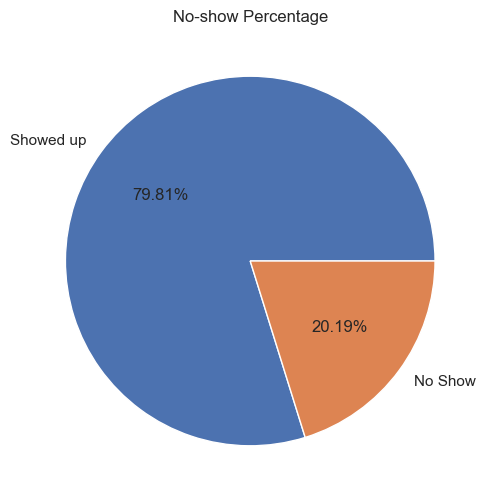

In [56]:
plt.figure(figsize=(10,6))
plt.pie(df['No-show'].value_counts(),labels=['Showed up','No Show'],autopct='%1.2f%%')
plt.title('No-show Percentage')
plt.show()

80% of patients overall showed up while the other 20% of patients were no shows

<Axes: xlabel='Age', ylabel='Count'>

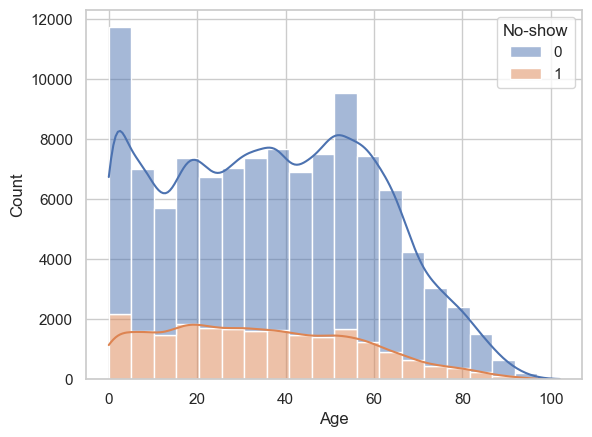

In [58]:
sns.histplot(data=df, x="Age", hue="No-show", multiple="stack",kde=True,  bins=20)

Ages from 0-60 there's about the same rate of no shows, while patients the age of 0, and around 55 have above average number of those that showed up.

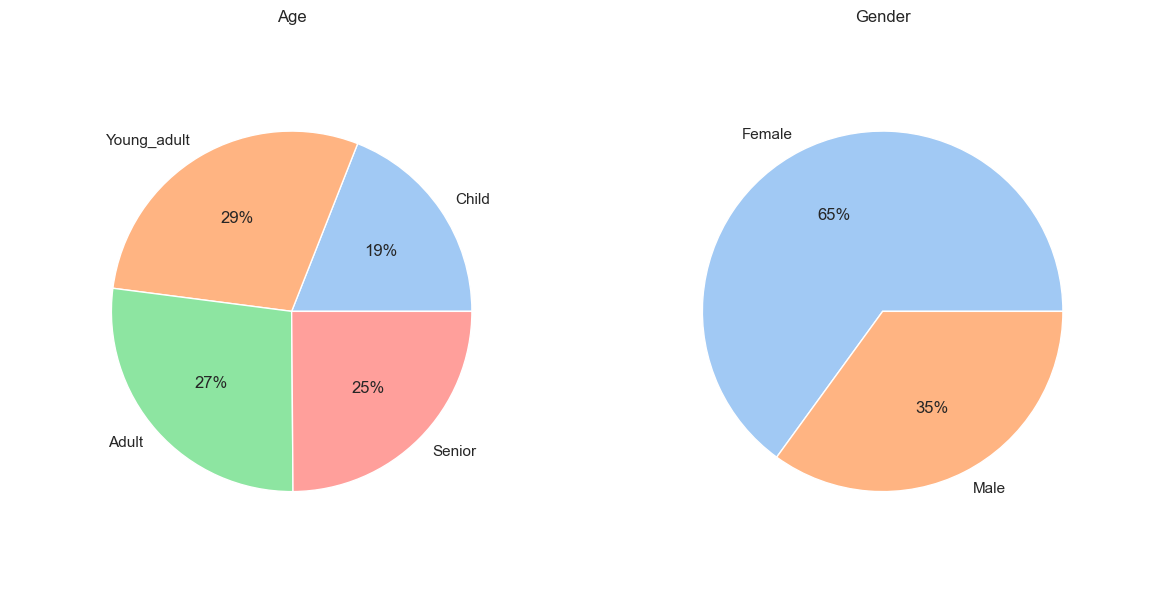

In [60]:
colors = sns.color_palette('pastel')[0:5]

# Create subplots with 2 rows and 2 columns
fig, axs = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for Age
df['age_group'] = pd.cut(df['Age'], bins=[0,12,35,55,102], labels=['Child','Young_adult','Adult','Senior'], include_lowest = True)
axs[0].pie(df.groupby('age_group').size(), labels=df.groupby('age_group').size().index, colors=colors, autopct='%.0f%%',radius=0.8)
axs[0].set_title("Age")

# Pie chart for Gender
axs[1].pie(df['Gender'].value_counts(), labels=['Female', 'Male'], colors=colors, autopct='%.0f%%',radius=0.8)
axs[1].set_title("Gender")

# Remove the 'bins' column from the data
df = pd.get_dummies(df, columns=['age_group'])
# Adjust layout and display
plt.tight_layout()
plt.show()

Above is the percentage of age ranges and genders.

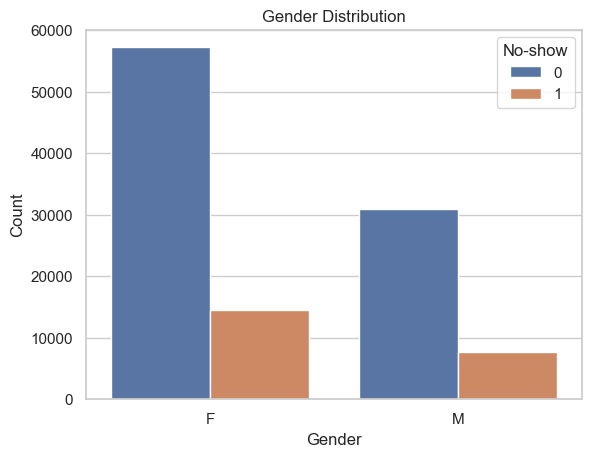

In [62]:
sns.countplot(x = 'Gender', data = df, hue = 'No-show')
plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

In [63]:
df['Gender'] = df['Gender'].map({'F': 0, 'M': 1})
df['Gender'] = df['Gender'].astype(int)

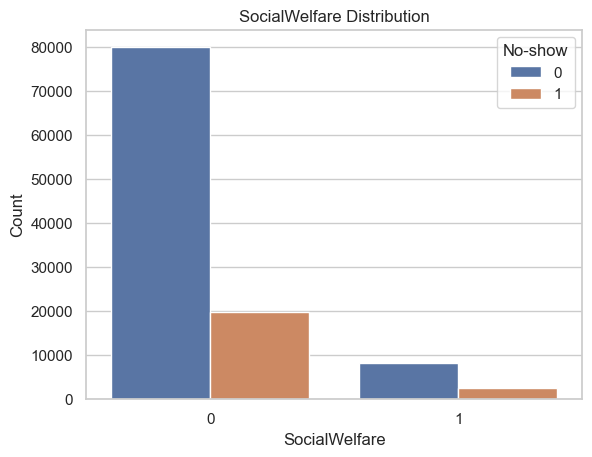

In [64]:
sns.countplot(x = 'SocialWelfare', data = df, hue = 'No-show')
plt.title('SocialWelfare Distribution')
plt.xlabel('SocialWelfare')
plt.ylabel('Count')
plt.show()

<Figure size 640x480 with 0 Axes>

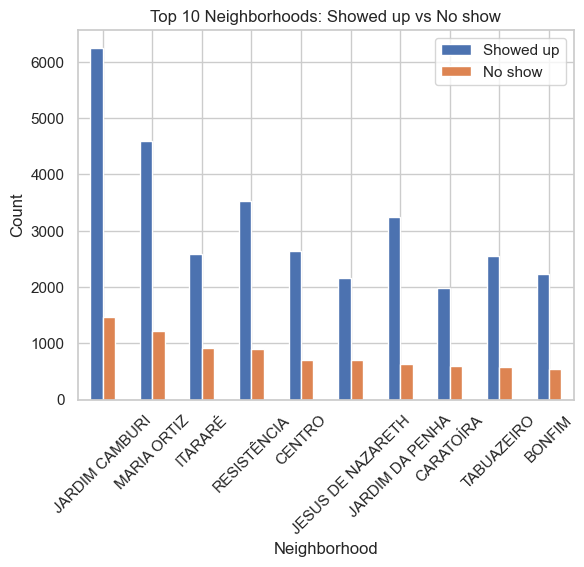

In [65]:
plt.figure()
top10N.plot(kind='bar')
plt.xlabel("Neighborhood")
plt.ylabel("Count")
plt.title("Top 10 Neighborhoods: Showed up vs No show")
plt.xticks(rotation=45)
plt.show()

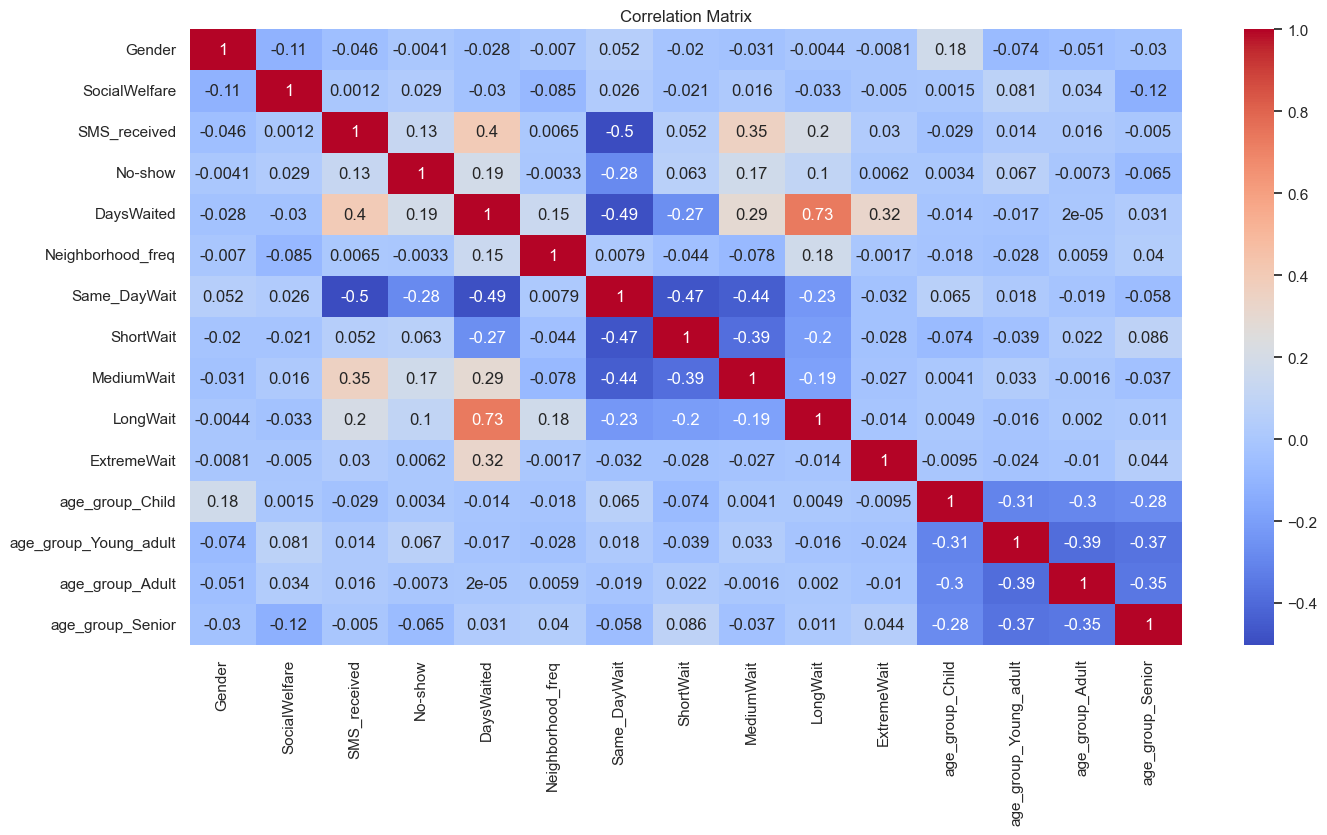

In [67]:
df =  df.drop(['Neighborhood', 'Age'], axis =1)
plt.figure(figsize=(16,8))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

SMS received and from DaysWaited the Medium Wait bin has the highest correlation with no shows and each other.

DaysWaited
0      38563
2       6725
4       5295
1       5213
7       4906
       ...  
139        1
132        1
117        1
146        1
123        1
Name: count, Length: 129, dtype: int64


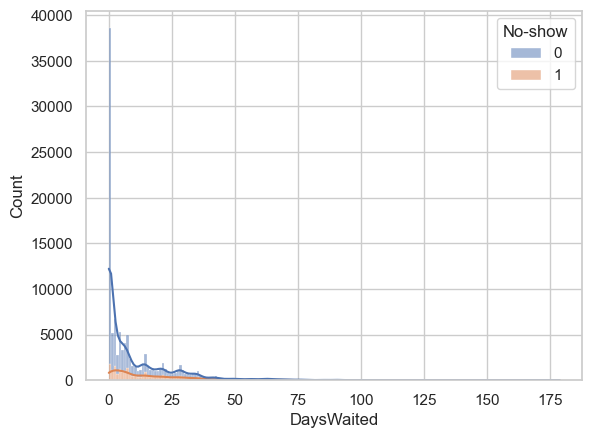

In [115]:
hist, bins = np.histogram(df['DaysWaited'], bins = df['DaysWaited'].sort_values(ascending = True).unique())
sns.histplot(data=df, x='DaysWaited', hue="No-show", multiple="stack",kde=True, bins=bins)

print(df['DaysWaited'].value_counts(ascending= False))

We can see the wait time these patients had before the appointment day were primarily 0 days. The bins for dayswaited will be very important in feature selection. 

# 4. Modeling

In [119]:
df.dtypes

Gender                     int64
SocialWelfare              int64
SMS_received               int64
No-show                    int64
DaysWaited                 int64
Neighborhood_freq        float64
Same_DayWait               int64
ShortWait                  int64
MediumWait                 int64
LongWait                   int64
ExtremeWait                int64
age_group_Child             bool
age_group_Young_adult       bool
age_group_Adult             bool
age_group_Senior            bool
dtype: object

In [121]:
X =df.drop(['No-show'], axis = 1)
y= df['No-show']

In [123]:
# train test and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [125]:
N_observations, N_features = X.shape
print('Number of Observations: ' + str(N_observations))
print('Number of Features: ' + str(N_features))

Number of Observations: 110527
Number of Features: 14


### Random Forest model

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')
# Determine set of hyperparameters

params = {
    "n_estimators": [100, 500],
    "max_depth": [5, 50],
    "min_samples_leaf": [1, 2, 4],
    'min_samples_split': [2, 15],
    "max_features": ["sqrt", "log2", None],
    "class_weight": ["balanced", None],
    'bootstrap': [True, False]
}
rfc = RandomForestClassifier(random_state=67, n_jobs=-1)
# Randomized Search CV
rf_random = RandomizedSearchCV(
    estimator=rfc,
    param_distributions=params,
    n_iter=25,             # number of random combinations to try
    scoring='roc_auc',     # metric to optimize
    cv=3,                  # 5-fold cross-validation
    verbose=1,
    n_jobs=-1,
    random_state=67,
    refit=True             # refit best model on full training data
)

# Fit to training data
rf_random.fit(X_train, y_train)

# Best hyperparameters
print("Best hyperparameters found:")
print(rf_random.best_estimator_)

In [127]:
rfc = RandomForestClassifier(n_estimators =217, max_depth= 9, min_samples_leaf= 5, min_samples_split=11, random_state=67)

In [129]:
print(rfc)

RandomForestClassifier(max_depth=9, min_samples_leaf=5, min_samples_split=11,
                       n_estimators=217, random_state=67)


In [131]:
rfc.fit(X_train, y_train)
# Get probabilities
y_probs = rfc.predict_proba(X_test)[:, 1]
# Manually set a lower threshold to force higher recall
y_pred = (y_probs >= 0.20).astype(int)

In [132]:
rfc.score(X_train, y_train)

0.7994820235012045

In [133]:
from sklearn.metrics import roc_auc_score, classification_report
roc_auc_score(y_test, y_probs)

0.7286763049216513

In [134]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.49      0.64     17650
           1       0.30      0.86      0.44      4456

    accuracy                           0.56     22106
   macro avg       0.61      0.67      0.54     22106
weighted avg       0.80      0.56      0.60     22106



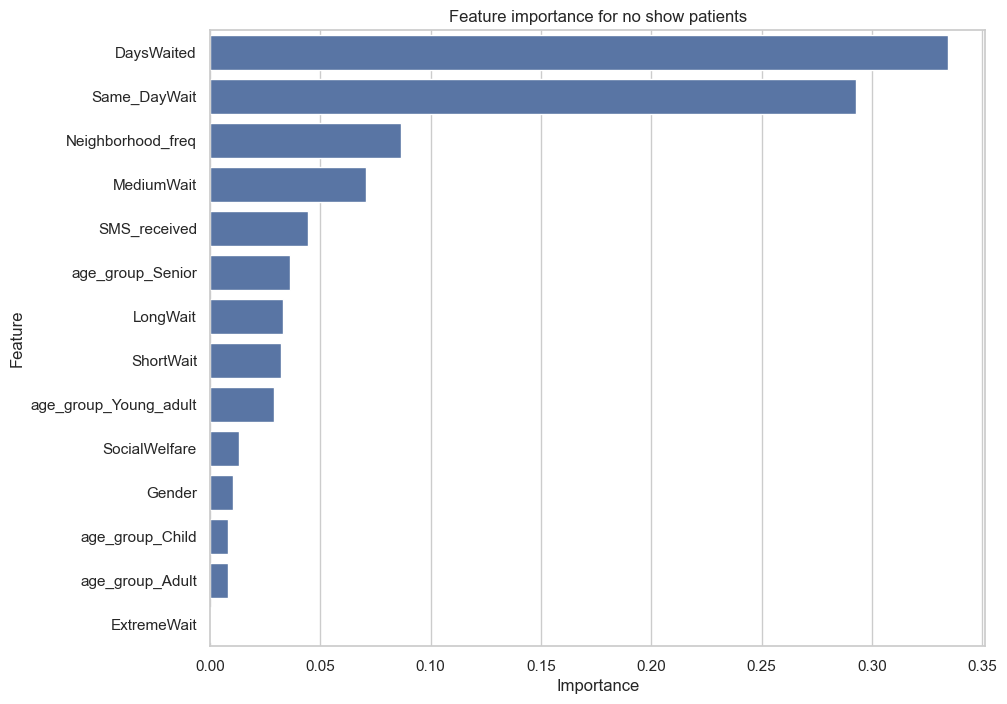

In [135]:
# 1. Map importances to column names
features = X_train.columns
importances = rfc.feature_importances_

# 2. Create a DataFrame for easy plotting
feat_imp_df = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False)

# 3. Plot it
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df)
plt.title('Feature importance for no show patients')
plt.show()

The Dayswaited feature and its segmentations seem to hold the highest importance.

In [143]:
pc_test = precision_score(y_test, y_pred)
rc_test = recall_score(y_test, y_pred)
ac_test = accuracy_score(y_test, y_pred)
f1_test = f1_score(y_test, y_pred)
print("The precision score is {pc:.3f}".format(pc = pc_test)) 
print("The recall score is {rc:.3f}".format(rc = rc_test))
print("The accuracy score is {ac:.3f}".format(ac = ac_test))
print("The F1 score is {f1:.3f}".format(f1 = f1_test))

The precision score is 0.297
The recall score is 0.858
The accuracy score is 0.561
The F1 score is 0.441


These metrics show a high recall of about .85 meaning the random forest model was able to identify **85%** of no shows. For example if there's **100** appointments with 20 no shows, **17** no shows would've been detected. however, the precision is low with about .3 this indicates that only **30%** of the patients predicted to not show up actually do. An example would be the model predicts **57** patients will not show up, but only **17** of them are true positives, while the rest are false positives(**40**). This indicates the model is good at catching no shows but it's over confident flagging many that do show up.

In [146]:
df.columns

Index(['Gender', 'SocialWelfare', 'SMS_received', 'No-show', 'DaysWaited',
       'Neighborhood_freq', 'Same_DayWait', 'ShortWait', 'MediumWait',
       'LongWait', 'ExtremeWait', 'age_group_Child', 'age_group_Young_adult',
       'age_group_Adult', 'age_group_Senior'],
      dtype='object')

In [148]:
df=df.drop(['Gender', 'SocialWelfare',
       'age_group_Child', 'age_group_Young_adult', 'age_group_Adult',
       'age_group_Senior', 'ExtremeWait', 'DaysWaited'], axis =1)

Dropped the attributes due to how low its importance was.

### XGBoost model

In [152]:
X =df.drop('No-show', axis = 1)

In [154]:
X.dtypes

SMS_received           int64
Neighborhood_freq    float64
Same_DayWait           int64
ShortWait              int64
MediumWait             int64
LongWait               int64
dtype: object

In [156]:
# train test and split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67)

In [158]:
xgb_model = XGBClassifier(
    n_estimators=300,          # more trees, but shallow
    max_depth=4,               # shallower than RF
    learning_rate=0.05,        # VERY important in boosting
    subsample=0.8,             # adds randomness
    colsample_bytree=0.8,      # feature sampling
    scale_pos_weight= len(y_train[y_train==0]) / len(y_train[y_train==1]),
    random_state=67,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)
y_probs_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [160]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    xgb_model,
    method="isotonic",
    cv=5
)

calibrated_model.fit(X_train, y_train)
y_proba_cal = calibrated_model.predict_proba(X_test)[:,1]

In [161]:
# Print ROC_AUC scores
roc_rf = roc_auc_score(y_test, y_probs)
roc_xgb = roc_auc_score(y_test, y_proba_cal)
print(f"RFC ROC-AUC:  {roc_rf:.3f}")
print(f"XGB ROC-AUC: {roc_xgb:.3f}")

RFC ROC-AUC:  0.729
XGB ROC-AUC: 0.710


In [162]:
y_pred2 = (y_proba_cal >= 0.20).astype(int)
print("RANDOM FOREST (Custom 0.20 Threshold)")
print(classification_report(y_test, y_pred))
print("\n XGBOOST (Calibrated + Custom 0.20 Threshold)")
print(classification_report(y_test, y_pred2))

RANDOM FOREST (Custom 0.20 Threshold)
              precision    recall  f1-score   support

           0       0.93      0.49      0.64     17650
           1       0.30      0.86      0.44      4456

    accuracy                           0.56     22106
   macro avg       0.61      0.67      0.54     22106
weighted avg       0.80      0.56      0.60     22106


 XGBOOST (Calibrated + Custom 0.20 Threshold)
              precision    recall  f1-score   support

           0       0.95      0.42      0.58     17650
           1       0.28      0.91      0.43      4456

    accuracy                           0.52     22106
   macro avg       0.62      0.66      0.51     22106
weighted avg       0.81      0.52      0.55     22106



The ROC-AUC score from XGBoost model doesn't change much from Random forest model. This signals the XGB model is still reliable.

In [164]:
pc_test = precision_score(y_test, y_pred2)
rc_test = recall_score(y_test, y_pred2)
ac_test = accuracy_score(y_test, y_pred2)
f1_test = f1_score(y_test, y_pred2)
print("The precision score is {pc:.3f}".format(pc = pc_test)) 
print("The recall score is {rc:.3f}".format(rc = rc_test))
print("The accuracy score is {ac:.3f}".format(ac = ac_test))
print("The F1 score is {f1:.3f}".format(f1 = f1_test))

The precision score is 0.283
The recall score is 0.911
The accuracy score is 0.517
The F1 score is 0.432


As we can see the the recall has increased to .91 showing that the model predicts **90%** of patients could potentially be no shows. The model is overconfident but in this instance it's useful due to the cost of reducing recall leading to missing potential no shows which is very costly.

### SHAP plots

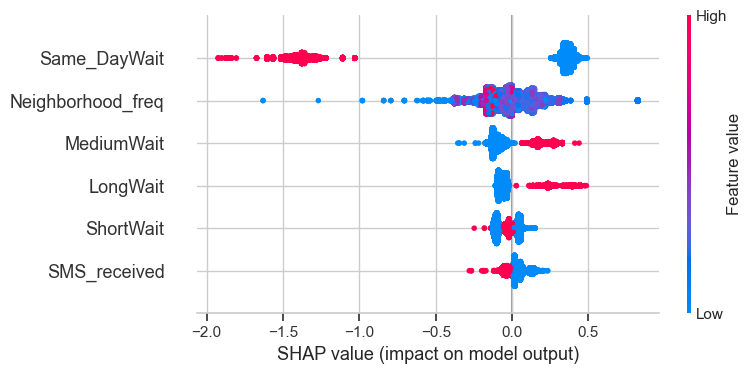

In [167]:
shap.initjs()
explainer = shap.TreeExplainer(xgb_model)
# Compute SHAP values
shap_values = explainer.shap_values(X_test)
# Global importance plot
shap.summary_plot(shap_values, X_test)

In [168]:
# Single prediction explanation
shap.force_plot(
    explainer.expected_value,
    shap_values[7],
    X_test.iloc[0]
)

The Force plot shows that the MediumWait and the Centro neighborhood pushes the risk significantly for this patient. Typically when there's no Same_DayWait and mediumWait is true the risk is higher. This is because Same_dayWait is the biggest anchor for patients that show up.

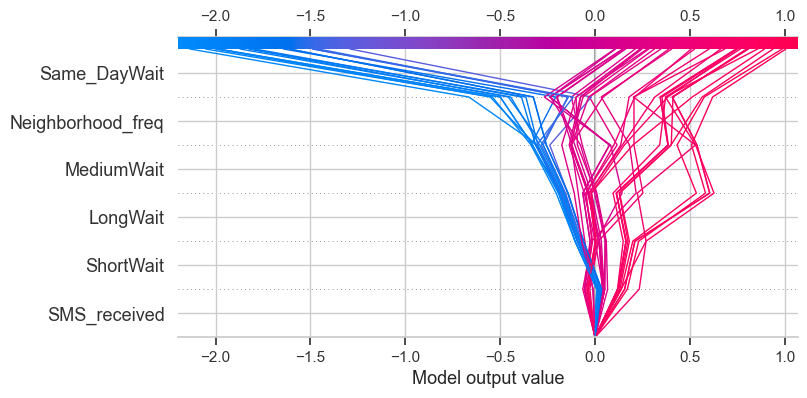

In [172]:
# Show path for both outcomes with 50 patients
shap.decision_plot(explainer.expected_value, shap_values[:50], X_test.iloc[:50])

Using SHAP decision plot to map the path for both outcomes shows not only the importance of the features, but also the attributes that are at risk for no shows and the attributes that don't have high no show rate but lean towards showing up. As we can see Same_DayWait attribute has the highest feature importance, but the decision plot indicates the output value lean more left leaning confirming that it is a strong predictor of patient attendence. Conversely, attributes like Neighborhood_freq, MediumWait, and LongWait have spikes towards the right, meaning they carry the most weight in predicting a patient no showing.

## Model evaluation and validation:

In [177]:
baselineR= y_test.mean()
print("Basline no show rate", baselineR)

Basline no show rate 0.20157423323984439


In [178]:
from sklearn.metrics import brier_score_loss

print("Brier (before):", brier_score_loss(y_test, y_probs_xgb))
print("Brier (after):", brier_score_loss(y_test, y_proba_cal))

Brier (before): 0.2192905801263425
Brier (after): 0.14629583683325614


In [179]:
baseline_brier = brier_score_loss(y_test, [y_test.mean()] * len(y_test))
print("Baseline Brier:", baseline_brier)

Baseline Brier: 0.1609420617336132


In [180]:
high_risk_share = (y_proba_cal >= 0.2).mean()
print(high_risk_share)

0.6490093187369945


This shows that the model proves a portion of 65% of patients has no show like behaviors(patients with Medium/Long wait).

In [182]:
df_eval_cal = pd.DataFrame({
    "y_true": y_test,
    "y_proba": y_proba_cal
})

# Create deciles (0 = lowest risk, 9 = highest risk)
df_eval_cal["decile"] = pd.qcut(df_eval_cal["y_proba"], 10, labels=False)

# Compute no-show rate per decile
decile_stats = df_eval_cal.groupby("decile").agg(
    mean_predicted_prob=("y_proba", "mean"),
    actual_no_show_rate=("y_true", "mean"),
    count=("y_true", "size")
)

print(decile_stats)

# Lift in top decile
top_decile_rate = decile_stats.loc[9, "actual_no_show_rate"]
lift = top_decile_rate / baselineR

print(f"\nTop decile no show rate: {top_decile_rate:.3f}")
print(f"Lift in top decile: {lift:.2f}x")

        mean_predicted_prob  actual_no_show_rate  count
decile                                                 
0                  0.029516             0.040505   2296
1                  0.040141             0.040826   2131
2                  0.050540             0.045946   2220
3                  0.153788             0.159193   2230
4                  0.232756             0.230628   2181
5                  0.246764             0.233453   2236
6                  0.266119             0.260303   2378
7                  0.292038             0.289862   2032
8                  0.334761             0.335005   2194
9                  0.388501             0.385417   2208

Top decile no show rate: 0.385
Lift in top decile: 1.91x


The top decile is 1.91× more likely to not show up than the average Patient.

In [184]:
df_sorted_cal = df_eval_cal.sort_values("y_proba", ascending=False)

top_20_cal = df_sorted_cal.head(int(0.20 * len(df_sorted_cal)))

avg_predicted_risk_cal = top_20_cal["y_proba"].mean()

expected_shows_double_cal = 2 * (1 - avg_predicted_risk_cal)

print("Avg predicted risk (top 20% calibrated):", avg_predicted_risk_cal)
print("Expected shows if double-booked:", expected_shows_double_cal)

Avg predicted risk (top 20% calibrated): 0.36153946353606686
Expected shows if double-booked: 1.2769210729278662


In [185]:
top_decile_idx = df_eval_cal[df_eval_cal['decile'] == 9].index

# Slice original X_test dataframe using indices
top_decile_features = X_test.loc[top_decile_idx]

# Create a comparison table: Top Decile vs the Overall Average
comparison_df = pd.DataFrame({
    'Top_Decile_Avg': top_decile_features.mean(),
    'Overall_Avg': X_test.mean()
})

# 4. Calculate a "Multiplier" to see which features are heavily over-represented
comparison_df['Difference_Multiplier'] = comparison_df['Top_Decile_Avg'] / comparison_df['Overall_Avg']

# 5. Display sorted by the biggest differences
comparison_df.sort_values(by='Difference_Multiplier', ascending=False)

,Top_Decile_Avg,Overall_Avg,Difference_Multiplier
LongWait,0.416667,0.095087,4.381938
MediumWait,0.583333,0.261332,2.232156
Neighborhood_freq,0.027784,0.024747,1.122757
SMS_received,0.151268,0.322582,0.468929
ShortWait,0.000000,0.295666,0.000000
Same_DayWait,0.000000,0.346150,0.000000


This Table confirms insights that would found in EDA phase, MediumWait has a **2.2** multiplier and LongWait has a **4.4** multiplier for top risky patients, with them averaging **99%** of top risky patients, validating insights found during the EDA phase.

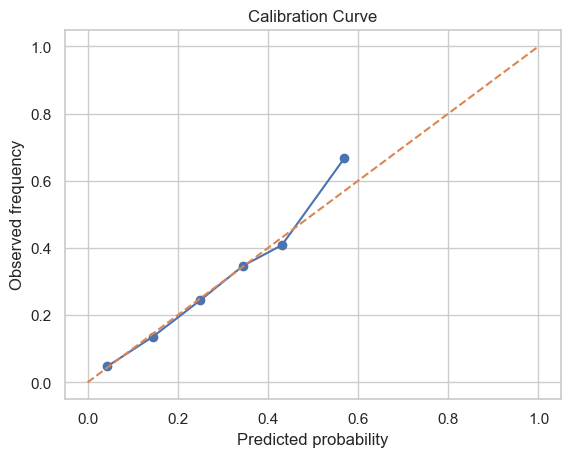

In [187]:
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

prob_true, y_pred2 = calibration_curve(y_test, y_proba_cal, n_bins=10)

plt.figure()
plt.plot(y_pred2, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("Predicted probability")
plt.ylabel("Observed frequency")
plt.title("Calibration Curve")
plt.show()

# 5. Conclusion & Operational Strategy

Based on the dataset and model outputs, wait time is the primary behavioral driver of patients not showing up to their appointments.

* **The High risk Zone**: Patients scheduled 7 or more days in advance (Medium Wait and Long Wait) are **30%-33%** more likely to miss appointments.

* **The Financial Impact**: According to Berg et al. (2013), the net loss of no-shows is typically about **16.4%** of net gain, scaling with the volume of no shows.

* **Targeted Intervention**: Implementing this model can minimize missed appointment costs by **3%–10%** by proactively identifying high-risk vacancies. To mitigate the clinic's average **20%** no-show rate, the clinic should implement Asymmetrical Overbooking. If a highly calibrated, at-risk patient (Medium Wait or Long Wait) is scheduled, the clinic can safely double-book that specific slot with a Same Day patient, whose no show risk is statistically near zero.

* **Volume Overbooking**: Alternatively, the clinic can overbook the total daily patient volume by 10% to absorb the high-risk no shows throughout the day, avoiding bottlenecks in any single, specific time slot.

### Sources:

[1]Berg BP, Murr M, Chermak D, Woodall J, Pignone M, Sandler RS, Denton BT. Estimating the cost of no-shows and evaluating the effects of mitigation strategies. Med Decis Making. 2013 Nov;33(8):976-85. doi: 10.1177/0272989X13478194. Epub 2013 Mar 20. PMID: 23515215; PMCID: PMC4153419.